In [ ]:
import shap
import pandas as pd
import numpy as np
import scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

import shap
import matplotlib.pyplot as plt

import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore")
import pickle

def p2_5(x):
    return np.percentile(x, 2.5)

def p97_5(x):
    return np.percentile(x, 97.5)

Mounted at /content/drive


In [ ]:
look_up_table = pd.read_csv("/content/drive/MyDrive/Risk_Protective_Project/Tables/look_up_table.csv")

In [ ]:
input_path = r"/content/drive/MyDrive/Risk_Protective_Project/Data/models.json"

with open(input_path, "rb") as f:
  mods = pickle.load(f)

model_dict = mods.copy()

In [ ]:
loop_table = []
for row in range(0 , len(look_up_table)):

    outcome_name = look_up_table.iloc[row]["outcome"]
    imputation_method = look_up_table.iloc[row]["imputation"]
    model_type = look_up_table.iloc[row]["model"]
    pre_process_type = look_up_table.iloc[row]["pre_process"]

    print(outcome_name , "|", imputation_method , "|",  model_type, "|", pre_process_type)

    best_model = model_dict[(outcome_name, imputation_method, pre_process_type,model_type)]


    params_df = (
        pd.DataFrame(
            best_model.get_params().items(),
            columns=["parameter", "value"]
            )
        )

    params_df['outcome'] = outcome_name
    params_df['imputation'] = imputation_method
    params_df['model'] =  model_type
    params_df['pre_process'] =   pre_process_type

    loop_table.append(params_df)

ideation | iter | rf | none
ideation | knn | lightgbm | none
suicideatt_qn29 | iter | xgb | class_weights
suicideatt_qn29 | knn | xgb | none


In [ ]:
params_wide = (
    pd.concat(loop_table, ignore_index=True).dropna(subset=["value"])
    .pivot(
        index=["outcome", "imputation", "model", "pre_process"],
        columns="parameter",
        values="value"
    )
    .reset_index()
)

params_wide.to_csv( "/content/drive/MyDrive/Risk_Protective_Project/Tables/model_para.csv", index=False)

In [ ]:
input_path = r"/content/drive/MyDrive/Risk_Protective_Project/Data/datasets.json"

with open(input_path, "rb") as f:
  datasets = pickle.load(f)

data_dict = datasets.copy()

model_parameters = pd.read_csv("/content/drive/MyDrive/Risk_Protective_Project/Tables/model_para.csv")
look_up_table = pd.read_csv("/content/drive/MyDrive/Risk_Protective_Project/Tables/look_up_table.csv")
feature_selection_process_df = pd.read_csv("/content/drive/MyDrive/Risk_Protective_Project/Data/feature_selection_process.csv")


# sFigure X

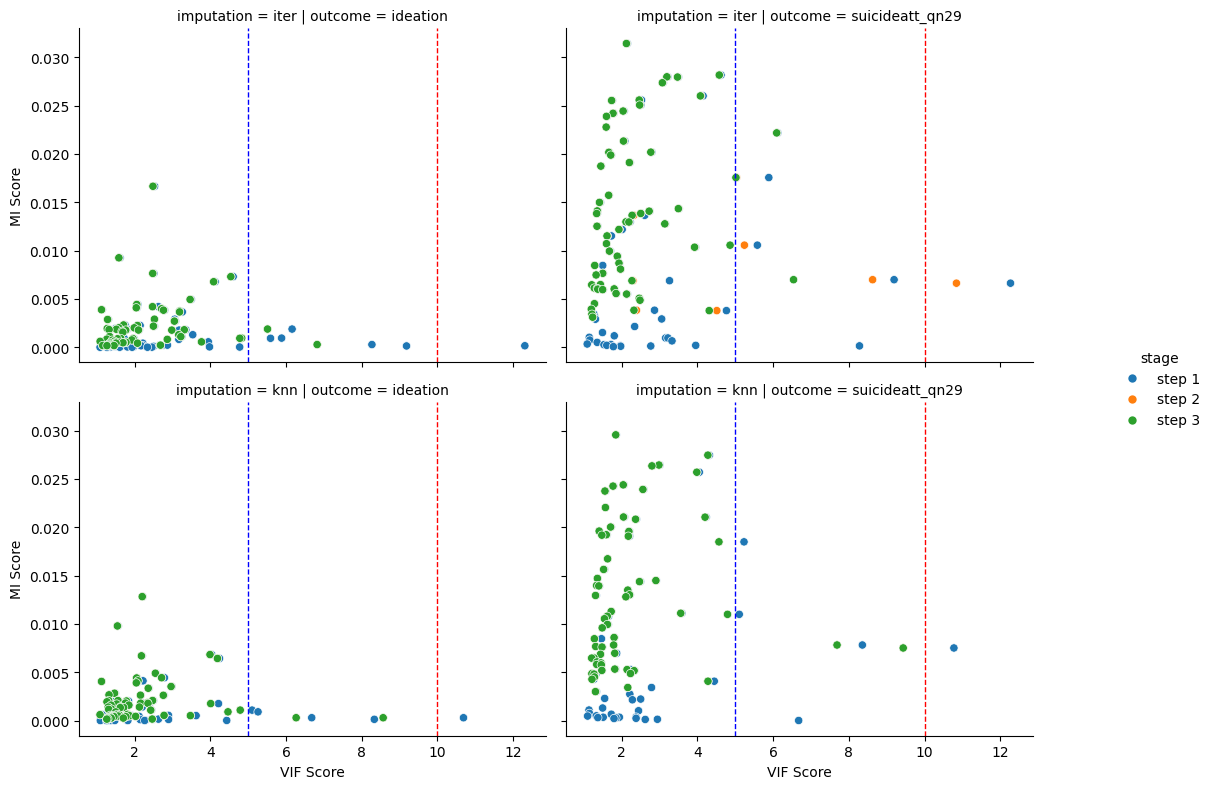

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.relplot(
    data=feature_selection_process_df,
    x="VIF",
    y="MI_score",
    col="outcome",
    row="imputation",
    hue="stage",
    kind="scatter",
    height=4,
    aspect=1.2
)

for ax in g.axes.flat:
    ax.axvline(5, color="blue", linestyle="--", linewidth=1)
    ax.axvline(10, color="red", linestyle="--", linewidth=1)

g.set_axis_labels("VIF Score", "MI Score")

g.legend.set_bbox_to_anchor((1.05, 0.5))
g.legend.set_loc("center left")
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Risk_Protective_Project/Figures/feature_selection_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ideation | iter | rf | none


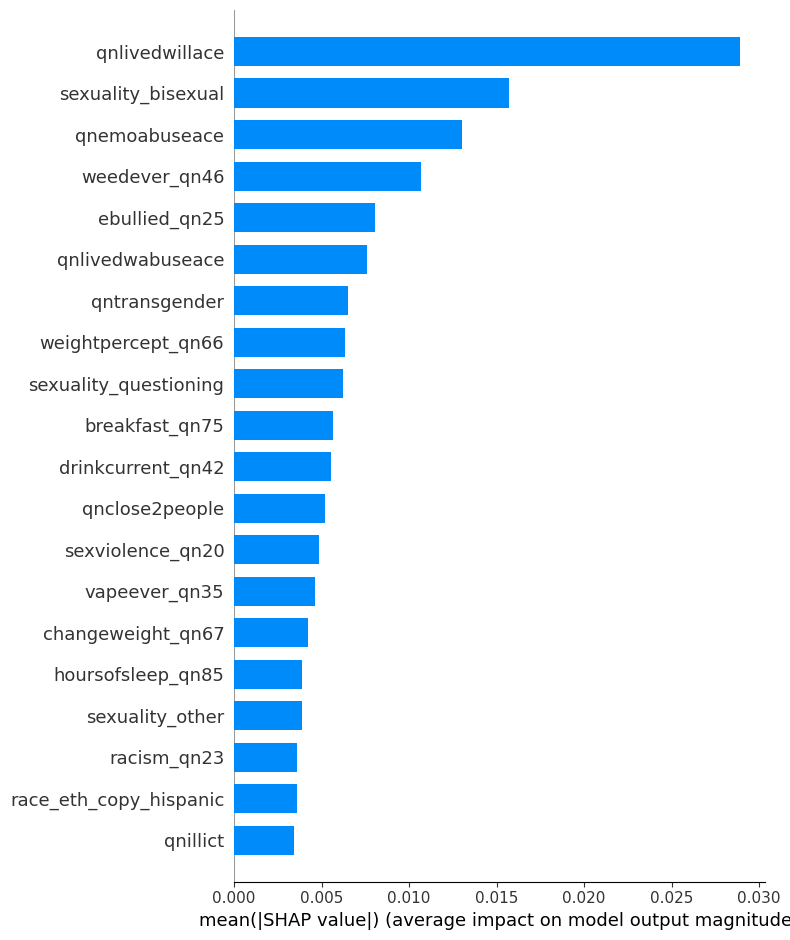

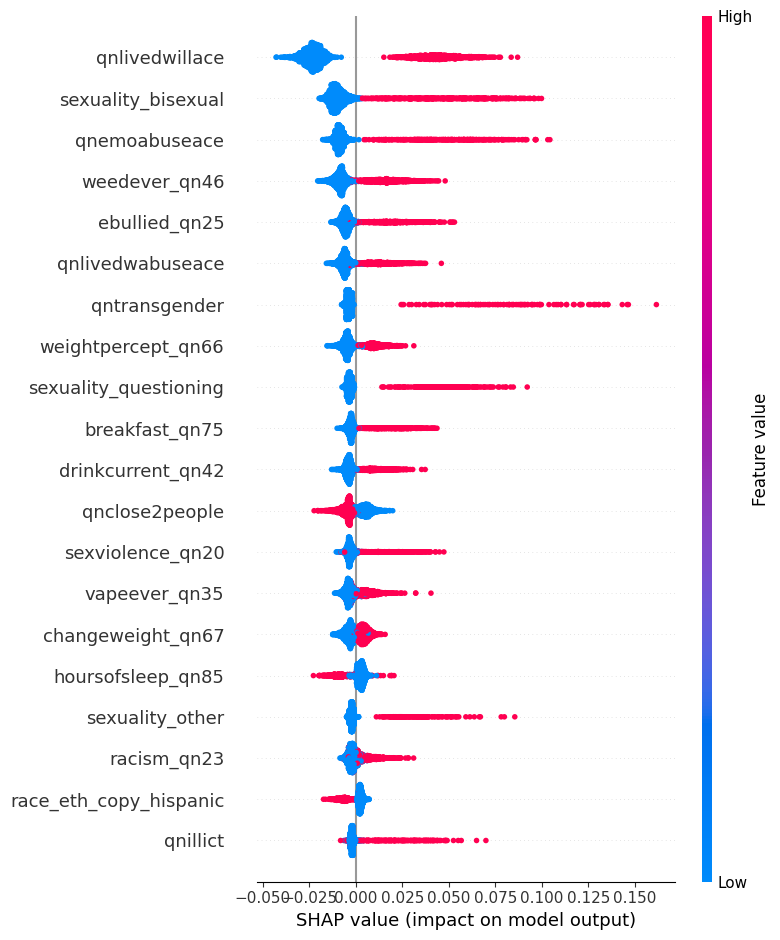

ideation | knn | lightgbm | none


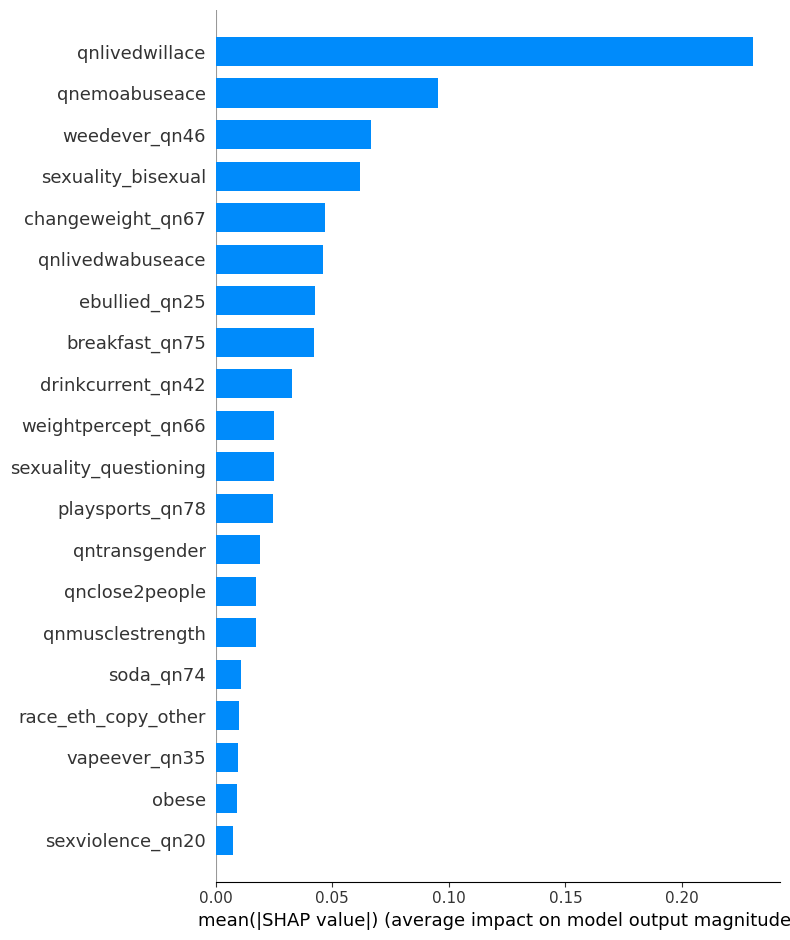

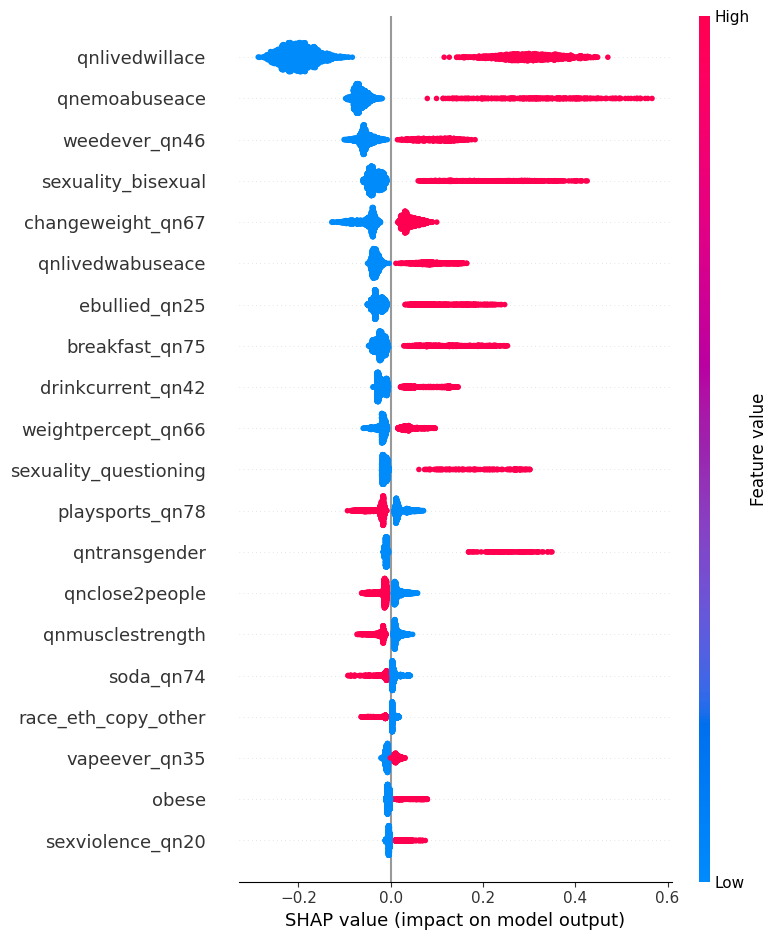

suicideatt_qn29 | iter | xgb | class_weights


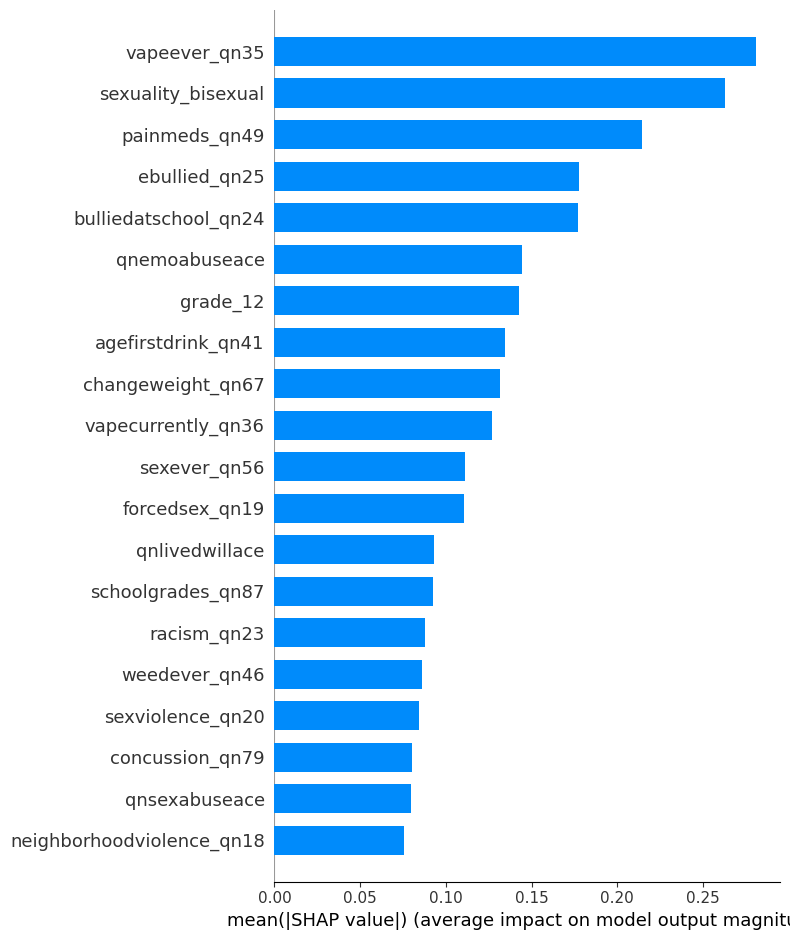

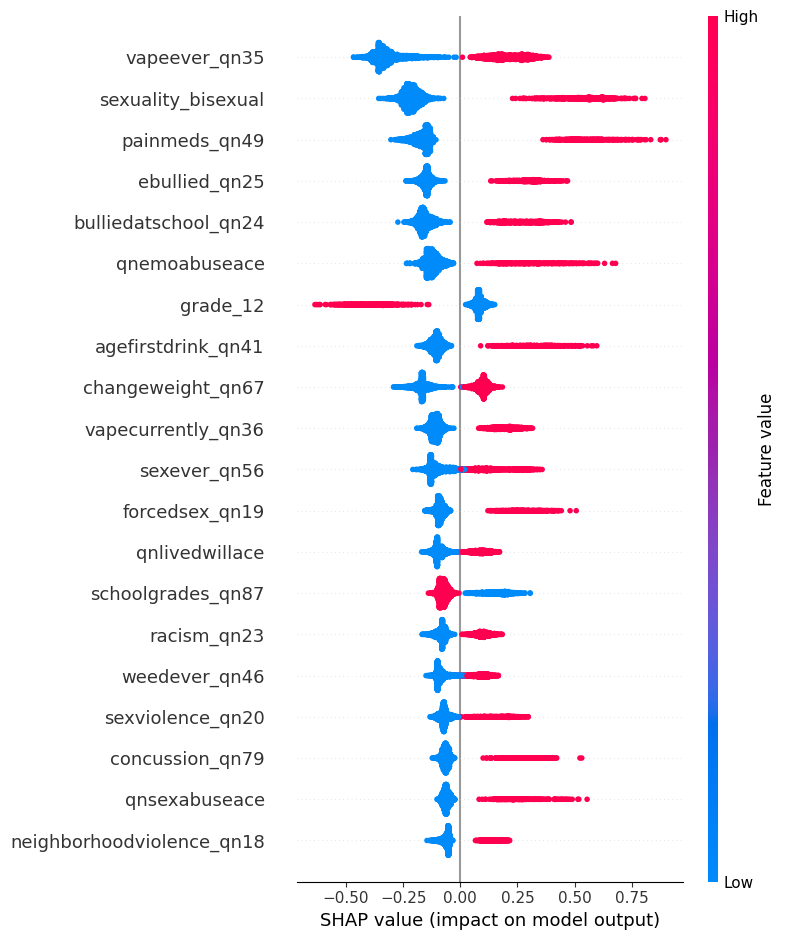

suicideatt_qn29 | knn | xgb | none


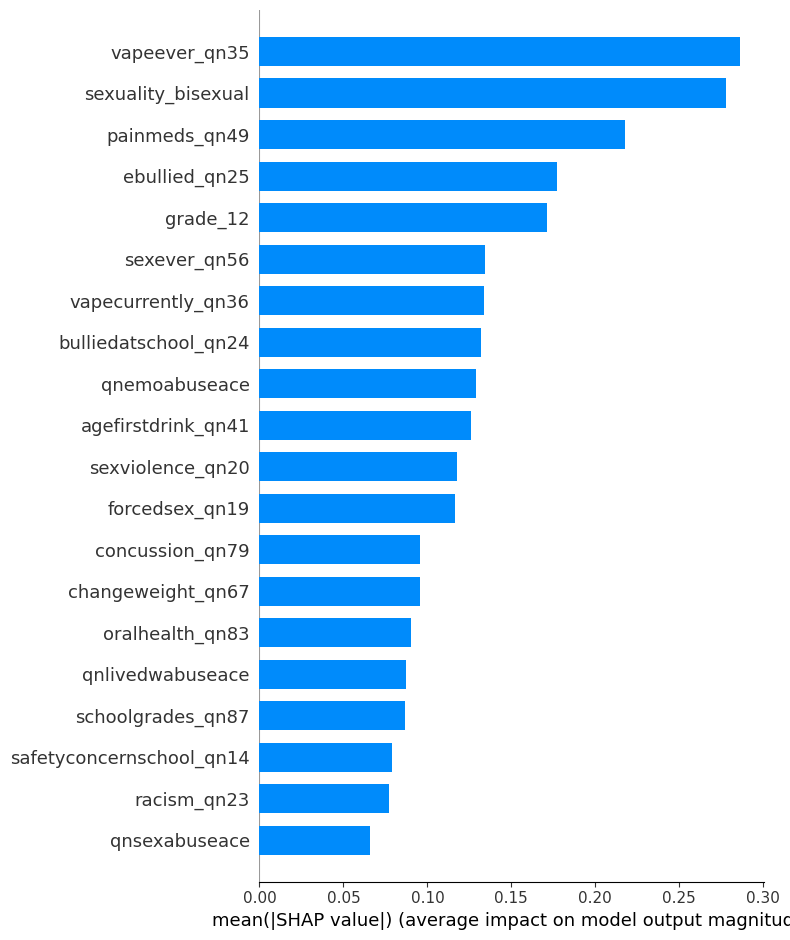

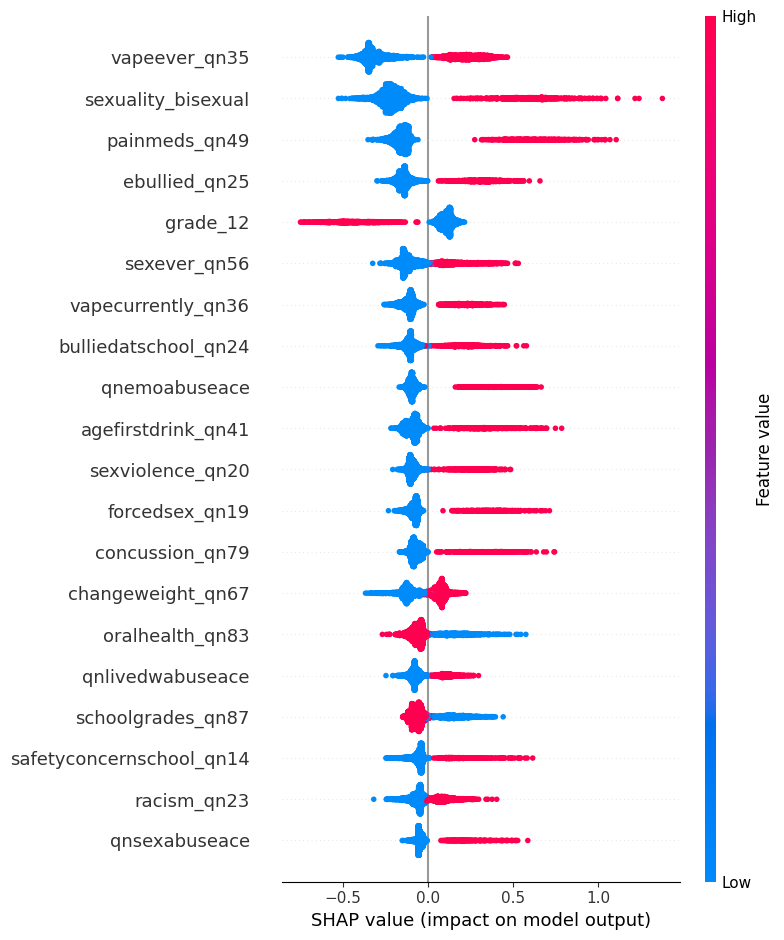

In [ ]:
import pandas as pd
import numpy as np
import shap
SEED = 123
raw_shaps = []
full_features = []
when_endorsed = []

for row in range(0 , len(look_up_table)):

    outcome_name = look_up_table.iloc[row]["outcome"]
    imputation_method = look_up_table.iloc[row]["imputation"]
    model_type = look_up_table.iloc[row]["model"]
    pre_process_type = look_up_table.iloc[row]["pre_process"]

    print(outcome_name , "|", imputation_method , "|",  model_type, "|", pre_process_type)

    filtered_para = model_parameters[
        (model_parameters["outcome"] == outcome_name) &
        (model_parameters["imputation"] == imputation_method) &
        (model_parameters["model"] == model_type) &
        (model_parameters["pre_process"] == pre_process_type)
        ].drop(columns=["outcome", "imputation", "model", "pre_process"])

    df_long = filtered_para.melt(
        var_name="Column",
        value_name="Value"
        ).dropna(subset=["Value"])

    params = dict(zip(df_long["Column"], df_long["Value"]))

    if(model_type == "rf"):
      params["n_estimators"] = int(params["n_estimators"])
      params["max_depth"] = int(params["max_depth"])
      params["min_samples_split"] = int(params["min_samples_split"])
      params["min_samples_leaf"] = int(params["min_samples_leaf"])
      params['verbose'] = int(params['verbose'])


      best_model = RandomForestClassifier(**params)

    elif (model_type == "lightgbm"):
      params["max_depth"] = int(params["max_depth"])
      params["min_child_samples"] = int(params["min_child_samples"])
      params["n_estimators"] = int(params["n_estimators"])
      params["num_leaves"] = int(params["num_leaves"])
      params["random_state"] = int(params["random_state"])
      params["subsample_for_bin"] = int(params["subsample_for_bin"])
      params["subsample_freq"] = int(params["subsample_freq"])
      params["verbose"] = int(params["verbose"])



      best_model = LGBMClassifier(**params)

    else:
      params['max_depth'] = int(params['max_depth'])
      params['min_child_weight'] = int(params['min_child_weight'])
      params['n_estimators'] = int(params['n_estimators'])

      best_model = model = XGBClassifier(**params)

    X_train = data_dict[(outcome_name, imputation_method, pre_process_type)]['X_train']
    y_train = data_dict[(outcome_name, imputation_method, pre_process_type)]['y_train']
    w_train = data_dict[(outcome_name, imputation_method, pre_process_type)]['w_train']

    X_test = data_dict[(outcome_name, imputation_method, pre_process_type)]['X_test']
    y_test = data_dict[(outcome_name, imputation_method, pre_process_type)]['y_test']
    w_test = data_dict[(outcome_name, imputation_method, pre_process_type)]['w_test']
    r_test = data_dict[(outcome_name, imputation_method, pre_process_type)]['r_test']


    best_model.fit(X_train, y_train, sample_weight=w_train)


    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):

      shap_values = shap_values[1]


    if(model_type == "rf"):

      shap.summary_plot(
        shap_values[:, :, 1],
        X_test,
        plot_type="bar"
        )

      shap.summary_plot(
        shap_values[:, :, 1],
        X_test
        )

    else:
      shap.summary_plot(
        shap_values,
        X_test,
        plot_type="bar"
        )

      shap.summary_plot(
        shap_values,
        X_test
        )


    X_test = X_test.reset_index(drop=True)
    r_test = pd.DataFrame(r_test).reset_index(drop=True)

    for exp_row in range(0, len(X_test)):

      if(model_type == "rf"):
        df = pd.DataFrame({
            "Feature": X_test.columns,
            "Feature_value": X_test.iloc[exp_row].values,
            "Race": r_test['race4'].iloc[exp_row],
            "Shap_value": shap_values[:, :, 1][exp_row ]
            })
        raw_shaps.append(df)

      else:
        df = pd.DataFrame({
            "Feature": X_test.columns,
            "Feature_value": X_test.iloc[exp_row].values,
            "Race": r_test['race4'].iloc[exp_row],
            "Shap_value": shap_values[exp_row ]
            })
        raw_shaps.append(df)

    full_shap_df = pd.concat(raw_shaps)

    # Finding top features - Overall
    overall_results = (
       full_shap_df
       .groupby(["Feature"])["Shap_value"]
       .agg(mean_abs_shap=lambda x: x.abs().mean())
       .reset_index()
       .pipe(lambda d: d[~d["Feature"].isin(['race_eth_copy_other','race_eth_copy_hispanic', "race_eth_copy_black"])]) # Dropping the race/eths from the feature selection list
        )

    overall_results['group'] = "Overall"

    # Finding top featues - Race/eth
    race_results = (
        full_shap_df
        .groupby(["Feature", "Race"])["Shap_value"]
        .agg(mean_abs_shap=lambda x: x.abs().mean())
        .reset_index()
        .pipe(lambda d: d[~d["Feature"].isin(['race_eth_copy_other','race_eth_copy_hispanic', "race_eth_copy_black"])])
        )

    race_results = race_results.rename(columns={"Race": "group"})

    combined_results = pd.concat([overall_results, race_results], axis=0)

    combined_results["outcome"] = outcome_name
    combined_results["imp"] = imputation_method
    combined_results["model"] = model_type
    combined_results["pre_process"] = pre_process_type

    full_features.append(combined_results)

   # Endorsed
    raw_shaps_endorsed =  full_shap_df[full_shap_df["Feature_value"] == 1].copy()

    overall_endorsed_results = (
       raw_shaps_endorsed
       .groupby(["Feature"])["Shap_value"]
       .agg(
           mean_shap = "mean",
           ci_lower = p2_5,
           ci_upper = p97_5,
           n = "count"
           )
        .reset_index()
        .pipe(lambda d: d[~d["Feature"].isin(['race_eth_copy_other','race_eth_copy_hispanic', "race_eth_copy_black"])])
        )

    overall_endorsed_results['group'] = "Overall"

    race_endorsed_results = (
        raw_shaps_endorsed
        .groupby(["Feature", "Race"])["Shap_value"]
        .agg(
            mean_shap = "mean",
            ci_lower = p2_5,
            ci_upper = p97_5,
            n = "count"
            )
        .reset_index()
        .pipe(lambda d: d[~d["Feature"].isin(['race_eth_copy_other','race_eth_copy_hispanic', "race_eth_copy_black"])])
        )

    race_endorsed_results = race_endorsed_results.rename(columns={"Race": "group"})

    combined_endorsed_results = pd.concat([overall_endorsed_results, race_endorsed_results], axis=0)

    combined_endorsed_results["outcome"] = outcome_name
    combined_endorsed_results["imp"] = imputation_method
    combined_endorsed_results["model"] = model_type
    combined_endorsed_results["pre_process"] = pre_process_type

    when_endorsed.append(combined_endorsed_results)


In [ ]:
feature_df = pd.concat(full_features, ignore_index=True)
feature_df_endorsed = pd.concat(when_endorsed, ignore_index=True)

In [ ]:
top10 = (
    feature_df.sort_values("mean_abs_shap", ascending=False)
      .groupby(["group", "outcome", "imp", "model", "pre_process"], group_keys=False)
      .head(20)
)

plot_feature_df = top10.merge(
    feature_df_endorsed,
    on=["Feature", "group", "outcome", "imp", "model", "pre_process"],
    how="left"
)

plot_feature_df["Label"] = np.select(
     [
                (plot_feature_df["mean_shap"] < 0) & (plot_feature_df["ci_upper"] < 0),
                (plot_feature_df["mean_shap"] > 0) & (plot_feature_df["ci_lower"] > 0),
                ],
        [
                    "*",
                    "*",
      ]

      ,
      default= " "
  )

plot_feature_df['mean_abs_shap_endorsed'] = plot_feature_df['mean_shap'].abs()


In [ ]:
plot_feature_df['Feature'].unique()


array(['sexuality_bisexual', 'vapeever_qn35', 'qnlivedwillace',
       'painmeds_qn49', 'ebullied_qn25', 'qnemoabuseace',
       'concussion_qn79', 'oralhealth_qn83', 'bulliedatschool_qn24',
       'grade_12', 'changeweight_qn67', 'weedever_qn46', 'breakfast_qn75',
       'qnlivedwabuseace', 'drinkcurrent_qn42', 'sexuality_questioning',
       'weightpercept_qn66', 'qntransgender', 'racism_qn23',
       'qnclose2people'], dtype=object)

In [ ]:

feature_map = {
    "qnlivedwillace": "Lived with a parent mental health factors (e.g., depression)",
    "qnlivedwabuseace": "Ever lived w/parent/guardian w/substance abuse",
    "weightpercept_qn66": "Describing oneself as slightly overweight or very overweight",
    "qntransgender": "Transgender",
    "qnclose2people": "Strongly agree or agree that they feel close to people at their school",
    "sexuality_bisexual": "Sexuality - Bisexual",
    "hoursofsleep_qn85": "8 or more hours of sleep at night",
    "soda_qn74": "Didn't drink soda in the last 7 days",
    "sexuality_questioning": "Sexuality - Questioning",
    "vapeever_qn35": "Have you ever used an electronic vapor product?",
    "qnemoabuseace": "Parental emotional abuse",
    "agefirstdrink_qn41": "First drank alcohol 12 or younger",
    "drinkcurrent_qn42":  "Drank at least 1 or more times in the last 30 days",
    "weedever_qn46": "Used marijuana 1 or more times in thier life",
    "ebullied_qn25": "Builled online in the last 12 months",
    "changeweight_qn67": "Trying to lose weight",
    "racism_qn23": "Experienced racism in at school (lifetime)",
    "breakfast_qn75": "Not eating breakfast in the last 7 days",
    "PEattendance_qn77": "Attended physical education (PE) class 1 or more times in a week",
    "grade_12": "Grade 12",
    "oralhealth_qn83": "Saw a dentist in the last 12 months",
    "concussion_qn79": "Had 1 or more concussions in the last 12 months",
    "bulliedatschool_qn24": "Builled at school in the last 12 months",
    "painmeds_qn49": "Missed used pain medications 1 or more times in thier life",
}

plot_feature_df["Feature"] = plot_feature_df["Feature"].map(feature_map)


outcome_map = {
    "ideation": "Suicidal Ideation Only (SI+)",
    "suicideatt_qn29": "Suicide Attempt (SA)"
}


plot_feature_df["outcome"] = plot_feature_df["outcome"].map(outcome_map)

group_map = {
    "Overall": "Overall",
    "white": "White",
    "black": "Black",
    "hispanic": "Latine",
    "other": "Other",
}


plot_feature_df["group"] = plot_feature_df["group"].map(group_map)


In [ ]:
plot_feature_df.to_csv( "/content/drive/MyDrive/Risk_Protective_Project/Data/plot_feature_df.csv", index=False)

In [ ]:
sig_finds = plot_feature_df[plot_feature_df['Label'] == "*"]
sig_finds.to_csv( "/content/drive/MyDrive/Risk_Protective_Project/Data/sig_finds.csv", index=False)

# Main Figure 1

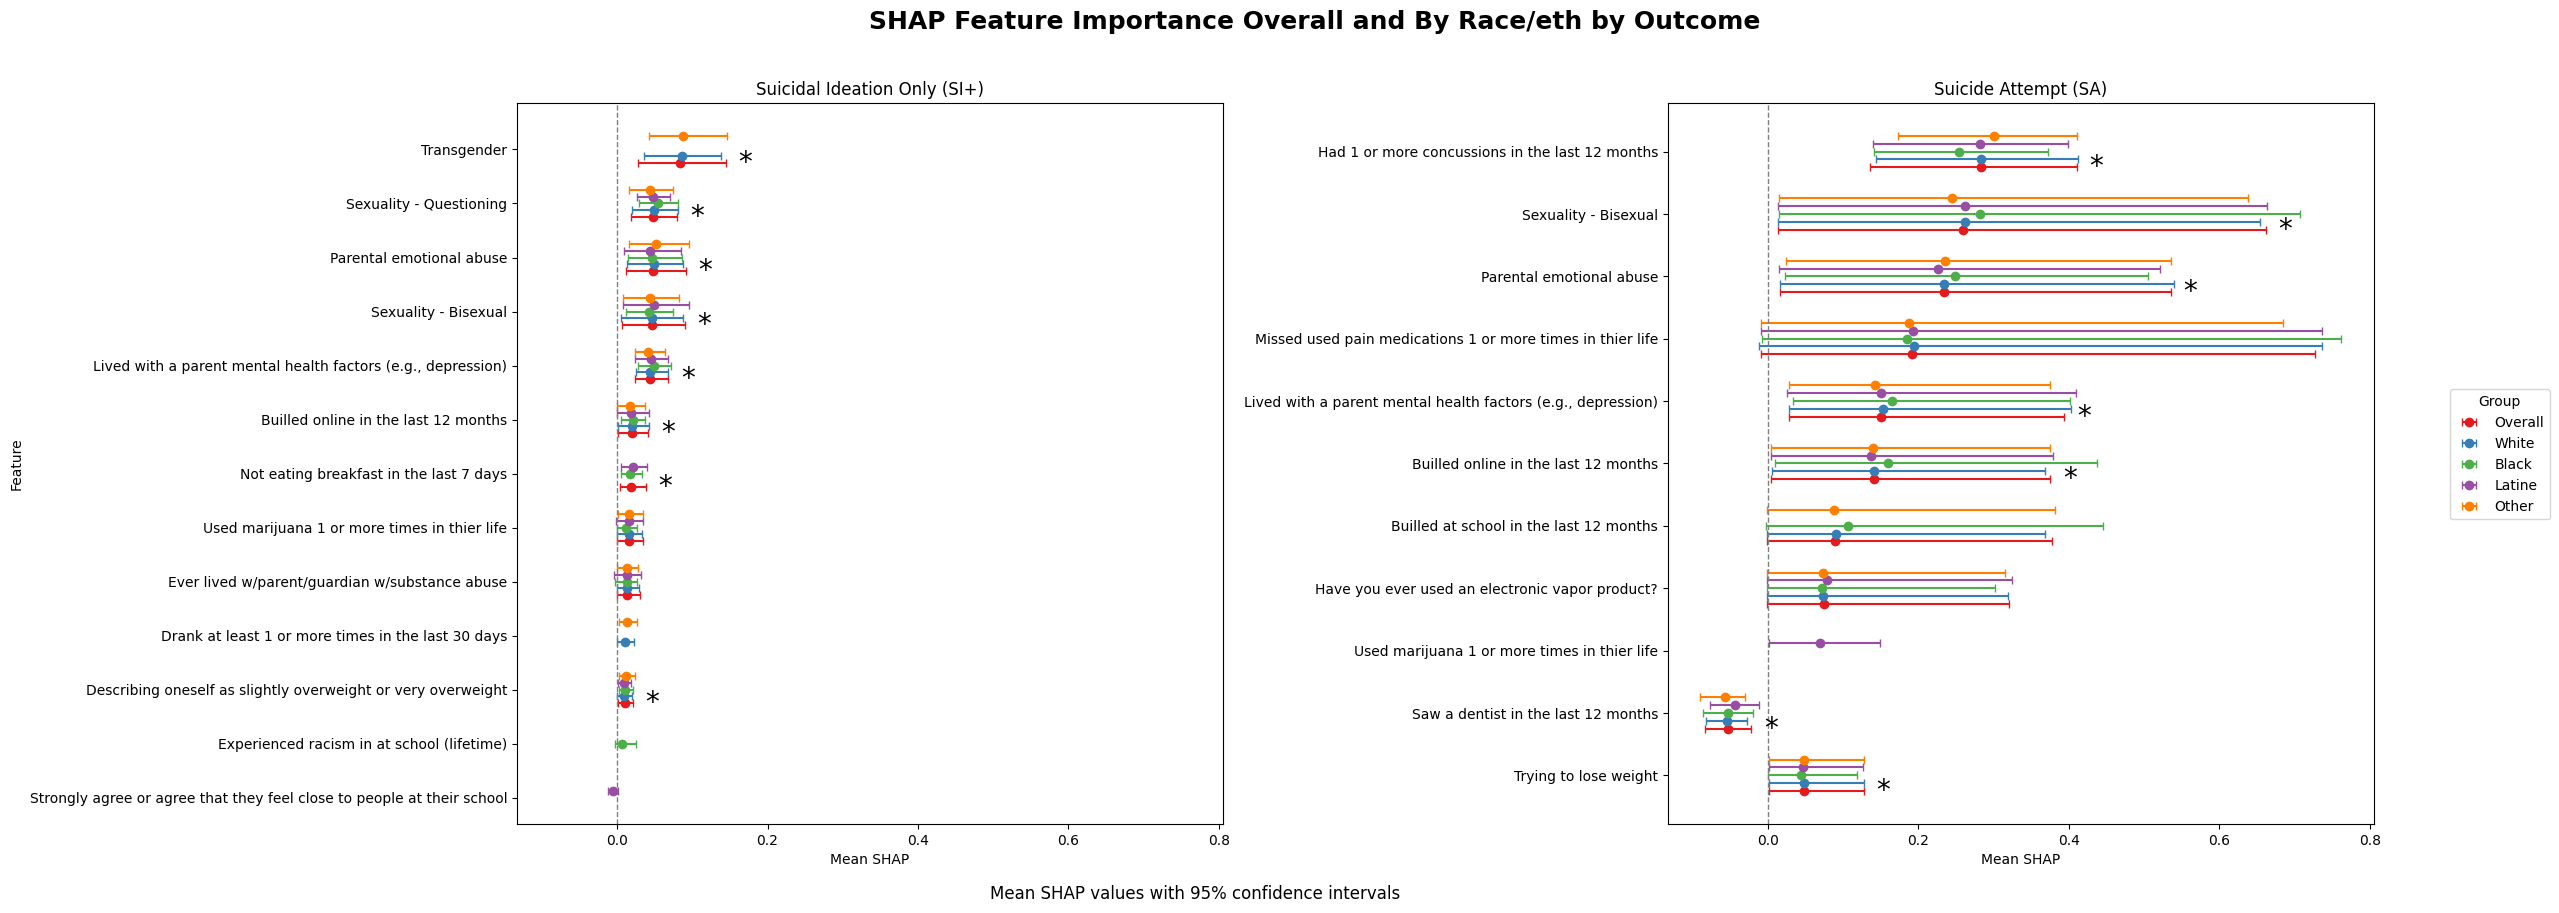

In [ ]:
df = plot_feature_df[(plot_feature_df["imp"] == "iter") ].copy()
group_order = [
    "Overall",
    "White",
    "Black",
    "Latine",
    "Other",
]

palette = sns.color_palette("Set1", n_colors=len(group_order))
color_dict = dict(zip(group_order, palette))

x_offset = 0.02 * (df["ci_upper"].max() - df["ci_lower"].min())

outcomes = ['Suicidal Ideation Only (SI+)','Suicide Attempt (SA)' ]

fig, axes = plt.subplots(
    1,
    len(outcomes),
    figsize=(12 * len(outcomes), 0.45 * df["Feature"].nunique()),
    sharex=True
)

if len(outcomes) == 1:
    axes = [axes]

for ax, outcome in zip(axes, outcomes):

    d = df[df["outcome"] == outcome].copy()

    feature_order = (
        d.groupby("Feature")["mean_abs_shap_endorsed"]
        .max()
        .sort_values(ascending=False)
        .index[::-1]
    )

    y_positions = {feature: i for i, feature in enumerate(feature_order)}

    groups = [g for g in group_order if g in d["group"].unique()]

    offsets = np.linspace(-0.25, 0.25, len(groups))

    for offset, group in zip(offsets, groups):

        dg = d[d["group"] == group]

        y = [y_positions[f] + offset for f in dg["Feature"]]

        xerr = np.vstack([
            dg["mean_shap"] - dg["ci_lower"],
            dg["ci_upper"] - dg["mean_shap"]
        ])

        ax.errorbar(
            dg["mean_shap"],
            y,
            xerr=xerr,
            fmt="o",
            color=color_dict[group],
            capsize=3,
            lw=1.5,
            label=group
        )

        if group == "Overall":
            for _, row in dg.iterrows():
                ax.text(
                    row["ci_upper"] + x_offset,
                    y_positions[row["Feature"]] + offset,
                    row["Label"],
                    va="center",
                    ha="left",
                    fontsize=20,
                    color="black"
                )

    ax.set_yticks(range(len(feature_order)))
    ax.set_yticklabels(feature_order)

    ax.set_title(outcome)
    ax.set_xlabel("Mean SHAP")
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)

axes[0].set_ylabel("Feature")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ordered_handles = [
    by_label[g]
    for g in group_order
    if g in by_label
]

ordered_labels = [
    g
    for g in group_order
    if g in by_label
]

fig.legend(
    ordered_handles,
    ordered_labels,
    title="Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

fig.suptitle(
    "SHAP Feature Importance Overall and By Race/eth by Outcome",
    fontsize=18,
    fontweight="bold",
    x=0.55,
    y=1.02
)

fig.text(
    0.5,
    -0.02,
    "Mean SHAP values with 95% confidence intervals",
    fontsize=12,
    ha="center"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Risk_Protective_Project/Figures/forest_plot_iter.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# sFigure X

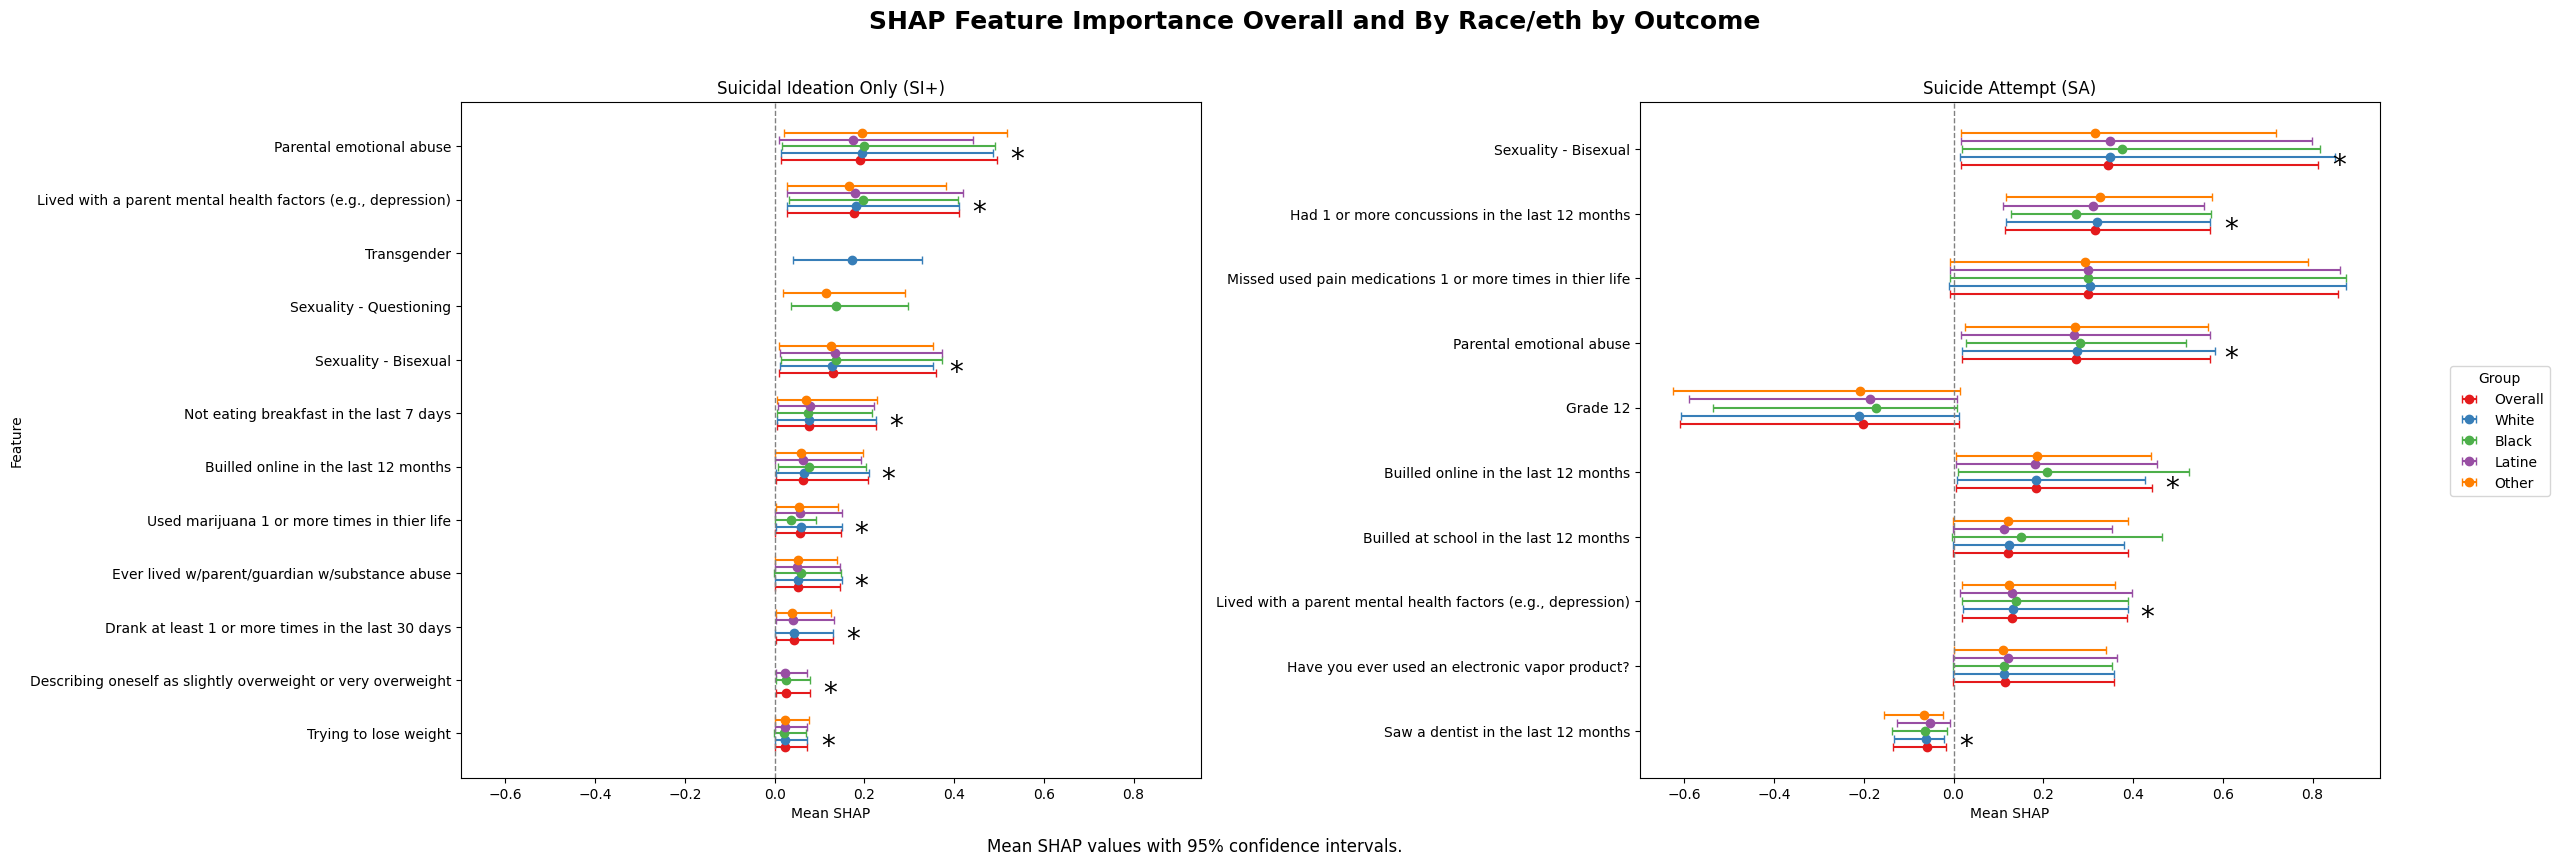

In [ ]:

df = plot_feature_df[(plot_feature_df["imp"] == "knn")].copy()

group_order = [
    "Overall",
    "White",
    "Black",
    "Latine",
    "Other",
]

palette = sns.color_palette("Set1", n_colors=len(group_order))
color_dict = dict(zip(group_order, palette))

x_offset = 0.02 * (df["ci_upper"].max() - df["ci_lower"].min())

outcomes = ['Suicidal Ideation Only (SI+)','Suicide Attempt (SA)' ]

fig, axes = plt.subplots(
    1,
    len(outcomes),
    figsize=(12 * len(outcomes), 0.45 * df["Feature"].nunique()),
    sharex=True
)

if len(outcomes) == 1:
    axes = [axes]

for ax, outcome in zip(axes, outcomes):

    d = df[df["outcome"] == outcome].copy()

    feature_order = (
        d.groupby("Feature")["mean_abs_shap_endorsed"]
        .max()
        .sort_values(ascending=False)
        .index[::-1]
    )

    y_positions = {feature: i for i, feature in enumerate(feature_order)}

    groups = [g for g in group_order if g in d["group"].unique()]

    offsets = np.linspace(-0.25, 0.25, len(groups))

    for offset, group in zip(offsets, groups):

        dg = d[d["group"] == group]

        y = [y_positions[f] + offset for f in dg["Feature"]]

        xerr = np.vstack([
            dg["mean_shap"] - dg["ci_lower"],
            dg["ci_upper"] - dg["mean_shap"]
        ])

        ax.errorbar(
            dg["mean_shap"],
            y,
            xerr=xerr,
            fmt="o",
            color=color_dict[group],
            capsize=3,
            lw=1.5,
            label=group
        )

        if group == "Overall":
            for _, row in dg.iterrows():
                ax.text(
                    row["ci_upper"] + x_offset,
                    y_positions[row["Feature"]] + offset,
                    row["Label"],
                    va="center",
                    ha="left",
                    fontsize=20,
                    color="black"
                )

    ax.set_yticks(range(len(feature_order)))
    ax.set_yticklabels(feature_order)

    ax.set_title(outcome)
    ax.set_xlabel("Mean SHAP")
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)

axes[0].set_ylabel("Feature")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ordered_handles = [
    by_label[g]
    for g in group_order
    if g in by_label
]

ordered_labels = [
    g
    for g in group_order
    if g in by_label
]

fig.legend(
    ordered_handles,
    ordered_labels,
    title="Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

fig.suptitle(
    "SHAP Feature Importance Overall and By Race/eth by Outcome",
    fontsize=18,
    fontweight="bold",
    x=0.55,
    y=1.02
)

fig.text(
    0.5,
    -0.02,
    "Mean SHAP values with 95% confidence intervals.",
    fontsize=12,
    ha="center"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Risk_Protective_Project/Figures/forest_plot_knn.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()